In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from obspy import read_inventory

In [ ]:
d25 = set(os.listdir("./Dec25Data/"))
d26 = set(os.listdir("./Dec26Data/"))
d27 = set(os.listdir("./Dec27Data/"))
d28 = set(os.listdir("./Dec28Data/"))
d29 = set(os.listdir("./Dec29Data/"))
d30 = set(os.listdir("./Dec30Data/"))
d31 = set(os.listdir("./Dec31Data/"))

stationsS = d25.intersection(d26,d27,d28,d29,d30,d31)
print(len(stationsS))
print(stationsS)

294
{'PY_BPH04', 'CI_KML', 'CI_BTP', 'CI_QAD', 'CI_FMO', 'CI_LBW2', 'CI_SRN', 'CI_BBS', 'CI_RMM', 'CI_CLO', 'CI_CVW', 'CI_BAW', 'CI_RIN', 'CI_RRX', 'CI_HDH', 'SB_VAFB1', 'CI_ABL', 'CI_BTL2', 'CI_GATR', 'CI_CSH', 'CI_KYV', 'SB_VAFB2', 'BK_WROK', 'CI_RSP', 'CI_IMP', 'CI_MPI', 'CI_IVY', 'NC_PZO', 'GM_KCS08', 'CI_YUH2', 'CI_WGR', 'CI_DAN', 'CI_STG', 'CI_TEJ', 'CI_RUS', 'CI_PUT', 'CI_SRA', 'CI_MTP', 'CI_LRL', 'CI_BOM', 'CI_SLM', 'CI_TOR', 'CI_MNO', 'CI_LRR2', 'CI_IDO', 'AZ_SIO5', 'CI_PER', 'CI_CZN', 'CI_CRY', 'AZ_SND', 'CI_HHL', 'CI_FMP', 'CI_SWS', 'PY_BPH08', 'CI_DTP', 'CI_MLS', 'CI_VLY', 'CI_DRE', 'PY_BPH10', 'AZ_LVA2', 'CI_LVY', 'PY_BPH06', 'YN_JORD', 'CI_LVO', 'CI_LGB', 'CI_DSC', 'CI_MGE', 'CI_DEC', 'CI_WWF', 'CI_BEL', 'CI_SRI', 'CI_SUN', 'CI_ERR', 'CI_GMA', 'CI_CDD', 'CI_HAR', 'CI_VLO', 'CI_HIW', 'CI_PZA', 'CI_PLM', 'PY_BPH13', 'CI_BAC', 'CI_BAI', 'CI_RUN', 'PY_BPH12', 'CI_SMR', 'CI_BLY', 'CI_PMD', 'CI_EML', 'CI_SLH', 'CI_RSI', 'CI_WSS', 'CI_PTD', 'CI_LCG', 'CI_EDW2', 'CI_BAK', 'CI_PSR

Found 294 unique stations from StationXML.


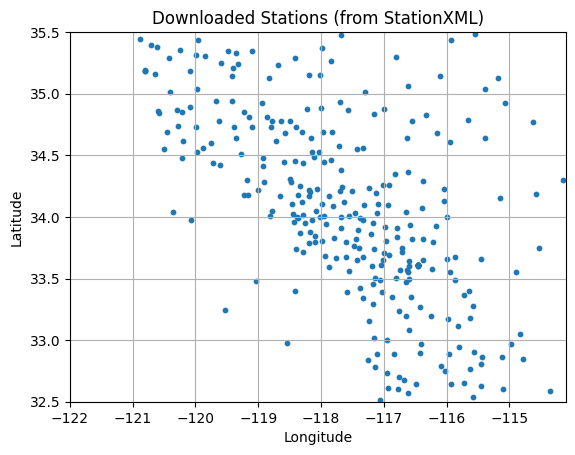

In [ ]:
DATA_MAIN = "./DEC25DATA/"

xml_files = { "./DEC25DATA/" + s + "/" + s.replace('_', '.') + ".xml" for s in stationsS }

stations = {}

for xf in xml_files:
    try:
        inv = read_inventory(xf)
    except Exception as e:
        continue

    for net in inv:
        for sta in net.stations:
            key = f"{net.code}.{sta.code}"
            lat = getattr(sta, "latitude", None)
            lon = getattr(sta, "longitude", None)
            if lat is None or lon is None:
                continue
            stations[key] = (float(lat), float(lon))

print(f"Found {len(stations)} unique stations from StationXML.")

lats = np.array([v[0] for v in stations.values()])
lons = np.array([v[1] for v in stations.values()])

plt.figure()
plt.scatter(lons, lats, s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Downloaded Stations (from StationXML)")

plt.xlim(-122.0, -114.1)
plt.ylim(32.5, 35.5)

plt.grid(True)
plt.show()